# testSCVIbatch.ipynb — cross-batch pair-MSE alignment loss

Inherits from `testRUVVAE_ZINB.ipynb` (uses the same TH subset + scVI-style
data prep). Calls [`model_scvi_batch_pair.SCVIWithBatchPairLoss`](model_scvi_batch_pair.py)
which adds an extra cross-batch MSE term to the standard scVI loss.

Pipeline:
1. Load data & prepare scVI format (counts in X, n_genes_on covariate)
2. `setup_anndata` + build `SCVIWithBatchPairLoss`
3. Forward validation: `pair_loss > 0` only when mini-batch has ≥ 2 batches
4. Train (100 epochs), watch `batch_pair_mse`
5. Evaluate alignment: iLISI / ASW vs baseline SCVI
6. Visualise: UMAP by batch, per-pair MSE convergence, latent `z` distribution

In [1]:
from scipy.sparse import csr_matrix, issparse
import numpy as np
import scanpy as sc
import pandas as pd


In [2]:
# ========== Load the same data subset as testRUVVAE_ZINB.ipynb ==========

adata = sc.read_h5ad(
    "/data3/junyi/scvi_harmony/TH_scviHarmony.h5ad"
)

# adata_subset = adata[
#     adata.obs["celltype.L2"].isin(
#         adata.obs["celltype.L2"].value_counts().head(2).index[1:2]
#     )
# ]
# adata_subset = adata_subset[adata_subset.obs["sex"] == "M"]

print(f"adata_subset shape: {adata.shape}")
print(f"status counts:\n{adata.obs['status'].value_counts()}")
print(f"company counts:\n{adata.obs['company'].value_counts()}")

adata_subset shape: (201921, 16428)
status counts:
status
CUSUS    55281
CON      53738
CURES    44435
CSRES    25445
CSSUS    23022
Name: count, dtype: int64
company counts:
company
beirui      144702
seekgene     36520
yunzhun      20699
Name: count, dtype: int64


In [10]:
LAYER_NAME = "scvi_nrom_counts_harmony"

In [4]:
adata.layers

Layers with keys: 'count_diff', 'counts', 'scvi_nrom_counts_harmony', 'scvi_reconstructed_counts_harmony', None

In [5]:
hkg_priority = [
    "Aars", "Sars",
    "Polr2a", "Polr2f",
    "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1",
    "Oaz1",
    "Rpl13a", "Rpl27", "Rps13", "Rps20",
    "Hprt1", "Gusb", "Ppia", "Ywhaz",
]

candidate_negative_control_genes = [
    "Oaz1", "Rps13", "Rps20", "Rpl27",
    "Aars", "Polr2f", "Psmd6", "Psmd7", "Psma5",
    "Ipo8", "Pop4", "Pes1", "Rer1",
    "Rpl13a", "Cyc1", "Sdha", "Ubc",
]

hkg_priority = candidate_negative_control_genes + hkg_priority


In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [7]:
adata.layers

Layers with keys: 'count_diff', 'counts', 'scvi_nrom_counts_harmony', 'scvi_reconstructed_counts_harmony', None

In [8]:
adata.layers['scvi_nrom_counts_harmony'].sum(axis=1)

array([10000.003, 10000.   , 10000.   , ...,  9999.999, 10000.001,
       10000.002], shape=(201921,), dtype=float32)

In [11]:
row_sums = adata.layers[LAYER_NAME].sum(axis=1)
if issparse(adata.layers[LAYER_NAME]):
    row_sums = np.asarray(row_sums).ravel()
else:
    row_sums = np.asarray(row_sums).ravel()

if np.allclose(row_sums, 1.0):
    adata.layers[LAYER_NAME] = adata.layers[LAYER_NAME] * 1e4
    print("每行 sum=1，已乘以 1e4")
else:
    print(f"未执行乘 1e4：行和并非全为 1（min={row_sums.min()}, max={row_sums.max()}）")


未执行乘 1e4：行和并非全为 1（min=9999.994140625, max=10000.005859375）


In [13]:
adata.layers["scvi_nrom_counts_harmony"].min()

np.float32(7.317773e-05)

In [14]:
adata.layers["scvi_norm"] =  adata.layers[LAYER_NAME].copy()


In [15]:
adata.layers

Layers with keys: 'count_diff', 'counts', 'scvi_nrom_counts_harmony', 'scvi_reconstructed_counts_harmony', None, 'scvi_norm'

In [16]:
mask = (adata.layers['scvi_reconstructed_counts_harmony'] == 0)

In [17]:
adata.layers["scvi_norm"][mask] = 0

In [18]:
adata.layers["scvi_norm"].min()

np.float32(0.0)

In [19]:

def to_sparse_int(arr, dtype=np.float32):
    """把 numpy / float / 稀疏数组转换成 (n_cells, n_genes) 的 csr int 矩阵。

    - 输入若为稀疏矩阵：保持格式，只把 dtype 转成 int32。
    - 输入若为稠密 ndarray：rint 截断后构造 csr（counts 必须是离散整数）。
    - 用于把 decoder 抽样得到的 counts 写入 adata.layers["..."]，避免 h5ad
      把 float 数组按 ~8 字节/元素存储（counts 通常很稀疏 + 数值小）。
    """
    if issparse(arr):
        return csr_matrix(arr).astype(dtype)
    arr = np.asarray(arr)
    if arr.ndim == 1:
        # 防御性：误传 1D 时强制 reshape 成单行矩阵
        arr = arr.reshape(1, -1)
    if dtype == np.int32: 
        return csr_matrix(np.rint(arr).astype(dtype))
    else:
        return csr_matrix(arr.astype(dtype))


In [20]:
layer_val = to_sparse_int(adata.layers["scvi_norm"], dtype=np.float32)
layer_val.eliminate_zeros()
adata.layers["scvi_norm"] = layer_val

In [21]:
globalmax = max(np.log(adata.layers["scvi_norm"].max()), np.log(adata.X.max()))


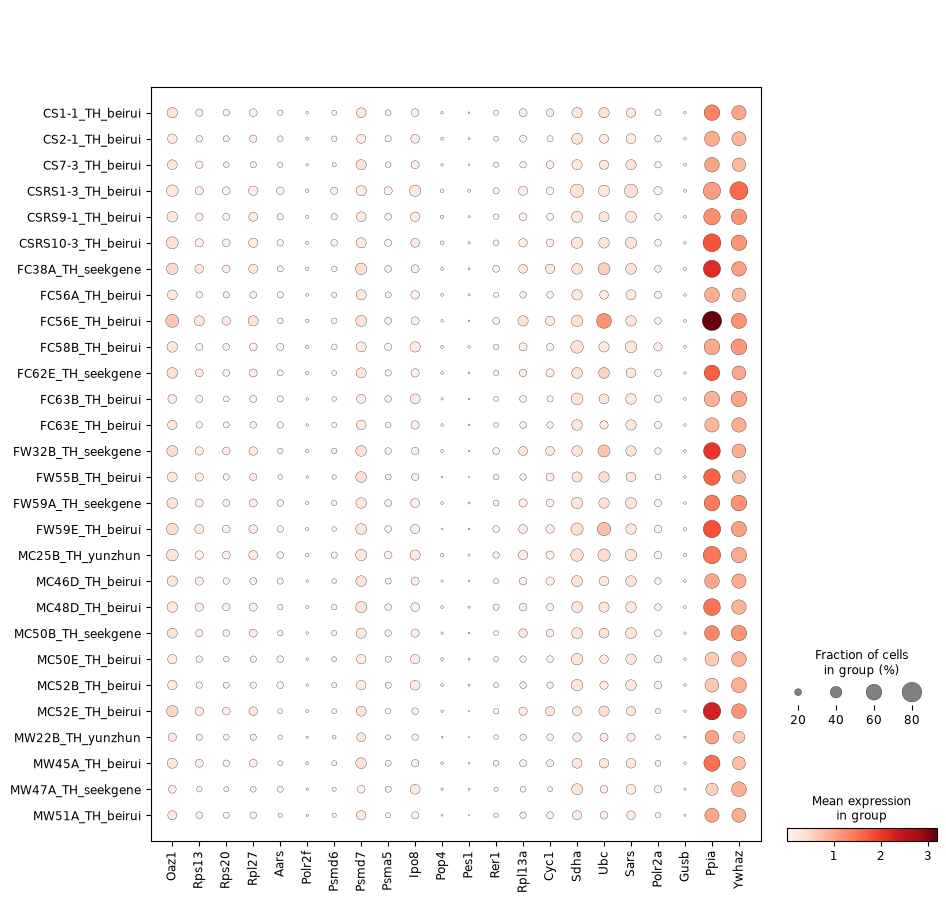

In [22]:
seen = set()
hkg_genes = []
for g in hkg_priority:
    if g in adata.var_names and g not in seen:
        seen.add(g)
        hkg_genes.append(g)

fig = sc.pl.dotplot(
    adata,
    var_names=hkg_genes,
    groupby="sample",
    layer="scvi_norm",
    swap_axes=False,
    dendrogram=False,
    return_fig=True,
)
fig.show()


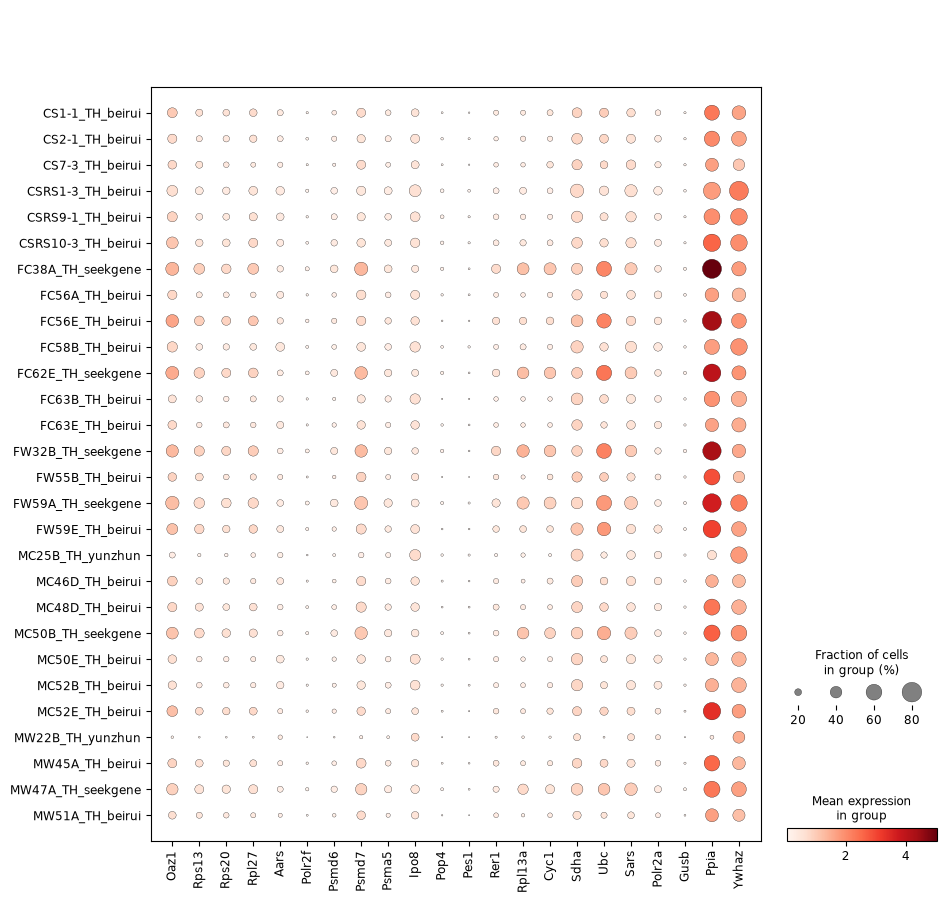

In [23]:

fig = sc.pl.dotplot(
    adata,
    var_names=hkg_genes,
    groupby="sample",
    swap_axes=False,
    dendrogram=False,
    return_fig=True,
)
fig.show()


In [24]:
# print the max,min,mean value of the normalized in batchpair_D1_normlized 
# print the max, min, mean value of the normalized data in adata.X
print(f"Max value in adata.X: {adata.X.max()}")
print(f"Min value in adata.X: {adata.X.min()}")
print(f"Mean value in adata.X: {adata.X.mean()}")


Max value in adata.X: 6111.92919921875
Min value in adata.X: 0.0
Mean value in adata.X: 0.6087167859077454


In [25]:
# print the max, min, mean value of the normalized data in adata.X
print(f"Max value in adata.X: {adata.layers['scvi_norm'].max()}")
print(f"Min value in adata.X: {adata.layers['scvi_norm'].min()}")
print(f"Mean value in adata.X: {adata.layers['scvi_norm'].mean()}")


Max value in adata.X: 3798.360595703125
Min value in adata.X: 0.0
Mean value in adata.X: 0.3738250732421875


In [27]:
sc.pp.log1p(adata)

In [28]:
sc.tl.rank_genes_groups(adata, groupby="company", method="wilcoxon",pct=True)

In [29]:
df_all = pd.DataFrame()
for company in adata.obs['company'].unique():
    print(f"Ranking genes for company: {company}")
    df_company = sc.get.rank_genes_groups_df(adata, group=company)
    df_company["company"] = company
    df_all = pd.concat([df_all, df_company], ignore_index=True)

Ranking genes for company: seekgene
Ranking genes for company: beirui
Ranking genes for company: yunzhun


In [30]:
df_all_filtered = df_all[df_all["pvals_adj"] < 0.05]

In [31]:
df_all_filtered.value_counts("company")

company
seekgene    11526
beirui      10284
yunzhun      9995
Name: count, dtype: int64

In [32]:
adata.layers["log1px"] = adata.X.copy()

In [33]:
adata.X = adata.layers["scvi_norm"].copy()

In [34]:
sc.pp.log1p(adata)

In [35]:
adata.layers["log1pscvi"] = adata.X.copy()

In [36]:
adata_con = adata[adata.obs["status"] == "CON"]

In [37]:
sc.tl.rank_genes_groups(adata_con, groupby="company", method="wilcoxon",pct=True)

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:829: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


In [38]:
df_con_correct = pd.DataFrame()
for company in adata_con.obs['company'].unique():
    print(f"Ranking genes for company: {company}")
    df_company = sc.get.rank_genes_groups_df(adata_con, group=company)
    df_company["company"] = company
    df_con_correct = pd.concat([df_con_correct, df_company], ignore_index=True)

Ranking genes for company: seekgene
Ranking genes for company: beirui
Ranking genes for company: yunzhun


In [39]:
df_con_correct_filtered = df_con_correct[df_con_correct["pvals_adj"] < 0.05]
df_con_correct_filtered.value_counts("company")

company
yunzhun     9480
seekgene    8148
beirui      5121
Name: count, dtype: int64

In [40]:
adata_con.X = adata_con.layers["log1px"].copy()
sc.tl.rank_genes_groups(adata_con, groupby="company", method="wilcoxon",pct=True)


In [41]:
df_raw = pd.DataFrame()
for company in adata_con.obs['company'].unique():
    print(f"Ranking genes for company: {company}")
    df_company = sc.get.rank_genes_groups_df(adata_con, group=company)
    df_company["company"] = company
    df_raw = pd.concat([df_raw, df_company], ignore_index=True)
df_raw_filtered = df_raw[df_raw["pvals_adj"] < 0.05]
print(f"Number of significant genes for each company:\n{df_raw_filtered.value_counts('company')}")

Ranking genes for company: seekgene
Ranking genes for company: beirui
Ranking genes for company: yunzhun
Number of significant genes for each company:
company
seekgene    9950
yunzhun     9444
beirui      8514
Name: count, dtype: int64


In [42]:
df_raw_filtered['absFC'] = df_raw_filtered['logfoldchanges'].abs()
df_con_correct_filtered['absFC'] = df_con_correct_filtered['logfoldchanges'].abs()

In [43]:
df_raw_filtered.groupby('company').agg({'absFC': ['mean', 'std']})

absFC          
              mean       std
company                     
beirui    0.429314  0.345569
seekgene  0.588980  0.446443
yunzhun   0.839529  0.770488

In [44]:
df_con_correct_filtered.groupby('company').agg({'absFC': ['mean', 'std']})

absFC          
              mean       std
company                     
beirui    0.259586  0.179553
seekgene  0.371212  0.219262
yunzhun   0.514496  0.215461

In [45]:
adata.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,predict.subclass,umap_seurat_1,umap_seurat_2,Neurotransmitter,doublet_cluster,celltype,Model,n_genes_on,_scvi_batch,_scvi_labels
AAACGAAAGTTCTAAC-1TH_seekgene_FC38A,FC38A_TH_seekgene,979,6.887553,1855.0,7.526179,43.018868,48.787062,58.005391,74.177898,5.0,...,NN,-0.612933,10.129816,NN,0,Arachnoid Barrier cell,CUSUS_F,-1.250766,0,0
AAACGAAAGCGCCGTT-1TH_seekgene_FC62E,FC62E_TH_seekgene,1142,7.041412,1594.0,7.374629,20.138018,27.540778,40.087829,59.723965,11.0,...,NN,0.026099,11.028849,NN,0,Arachnoid Barrier cell,CUSUS_F,-1.128574,0,0
AAACGAACATGGCCTG-1TH_seekgene_FW32B,FW32B_TH_seekgene,1005,6.913737,1835.0,7.515345,38.038147,45.068120,55.967302,72.479564,18.0,...,NN,-1.425823,8.482402,NN,0,Arachnoid Barrier cell,CON_F,-1.226984,0,0
AAACGAAGTCCTACGG-1TH_seekgene_FW32B,FW32B_TH_seekgene,933,6.839476,1886.0,7.542744,45.334040,51.484624,61.134677,77.041357,2.0,...,NN,-0.580119,9.640196,NN,0,Arachnoid Barrier cell,CON_F,-1.289310,0,0
AAACCCACACACCTTC-1TH_beirui_FW59E,FW59E_TH_beirui,1823,7.508787,3229.0,8.080237,25.301951,31.712605,40.786621,59.027563,5.0,...,NN,4.613636,3.108754,NN,0,Astrocyte-1,CON_F,-0.555334,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GGGCCATTCGATTTCT-1TH_beirui_CSRS10-3,CSRS10-3_TH_beirui,1459,7.286192,2407.0,7.786552,27.295388,33.527212,42.501039,60.157873,4.0,...,NN,7.775192,-3.685193,NN,0,VLMC,CSRES_M,-0.863686,0,0
TCATACTGTGTGTCCG-1TH_beirui_CSRS10-3,CSRS10-3_TH_beirui,1270,7.147559,2054.0,7.628031,29.065239,35.491723,45.228822,62.512171,3.0,...,NN,8.526631,2.918004,NN,0,VLMC,CSRES_M,-1.007201,0,0
TCTTGCGTCAGACCTA-1TH_beirui_CSRS1-3,CSRS1-3_TH_beirui,1255,7.135687,2028.0,7.615298,29.043393,35.108481,44.970414,62.771203,2.0,...,NN,-1.693517,-14.056318,NN,1,VSMC,CSRES_M,-1.023603,0,0
GGTTCTCGTCCATCTC-1TH_beirui_CSRS9-1,CSRS9-1_TH_beirui,1032,6.940222,1742.0,7.463363,36.222732,41.963261,52.238806,69.460390,3.0,...,NN,-1.547843,-13.610380,NN,0,VSMC,CSRES_M,-1.206482,0,0


In [46]:
df_status_raw = pd.DataFrame()
adata.X = adata.layers["log1px"].copy()
for status in adata.obs.status.unique():
    adata_disease = adata[(adata.obs.status == status) | (adata.obs.status == "CON") ]
    sc.tl.rank_genes_groups(adata_disease, groupby="status", method="wilcoxon",pct=True)
    df_status_tmp = sc.get.rank_genes_groups_df(adata_disease, group=status)
    df_status_tmp["status"] = status
    df_status_raw = pd.concat([df_status_raw, df_status_tmp], ignore_index=True)

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:829: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:829: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:393: RuntimeWarning: invalid value encountered in divide
  self.means_rest = (total - group_counts[:k, None] * mean[:k]) / n_rest
/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:529: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (
/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_grou

In [47]:
df_status_raw_filtered = df_status_raw[df_status_raw["pvals_adj"] < 0.05]

In [48]:
df_status_raw_filtered['Direction'] = df_status_raw_filtered['logfoldchanges'].apply(lambda x: 'up' if x > 0 else 'down')

In [49]:
df_status_raw_filtered

,names,scores,logfoldchanges,pvals,pvals_adj,status,Direction
0,Gm42418,39.949219,0.166766,0.000000e+00,0.000000e+00,CUSUS,up
1,Luc7l2,36.547466,0.178427,1.956359e-292,1.071302e-288,CUSUS,up
2,Gphn,34.470169,0.143234,2.245805e-260,9.223523e-257,CUSUS,up
3,Nr3c1,30.269165,0.349461,2.919444e-201,6.851517e-198,CUSUS,up
4,Qk,28.547539,0.278817,3.013698e-179,6.188629e-176,CUSUS,up
...,...,...,...,...,...,...,...
82135,Itm2b,-52.324932,-0.360789,0.000000e+00,0.000000e+00,CSRES,down
82136,Son,-59.287983,-0.362101,0.000000e+00,0.000000e+00,CSRES,down
82137,Luc7l3,-62.709621,-0.518048,0.000000e+00,0.000000e+00,CSRES,down
82138,Rbm39,-63.349548,-0.250188,0.000000e+00,0.000000e+00,CSRES,down


In [50]:
df_status_corrected = pd.DataFrame()
adata.X = adata.layers["log1pscvi"].copy()
for status in adata.obs.status.unique():
    adata_disease = adata[(adata.obs.status == status) | (adata.obs.status == "CON")]
    sc.tl.rank_genes_groups(adata_disease, groupby="status", method="wilcoxon", pct=True)
    df_status_tmp = sc.get.rank_genes_groups_df(adata_disease, group=status)
    df_status_tmp["status"] = status
    df_status_corrected = pd.concat([df_status_corrected, df_status_tmp], ignore_index=True)

/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:829: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:829: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:393: RuntimeWarning: invalid value encountered in divide
  self.means_rest = (total - group_counts[:k, None] * mean[:k]) / n_rest
/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:529: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (
/home/junyichen/anaconda3/envs/scvi-env/lib/python3.12/site-packages/scanpy/tools/_rank_genes_grou

In [51]:
adata.X.max()

np.float32(8.242588)

In [52]:
df_status_corrected_filtered = df_status_corrected[df_status_corrected["pvals_adj"] < 0.05]

In [53]:
df_status_corrected_filtered

,names,scores,logfoldchanges,pvals,pvals_adj,status
0,Luc7l2,57.715099,0.156762,0.0,0.0,CUSUS
1,Pafah1b1,54.185555,0.261885,0.0,0.0,CUSUS
2,Zfp638,45.905182,0.290664,0.0,0.0,CUSUS
3,Atrx,43.374947,0.227419,0.0,0.0,CUSUS
4,Stag1,42.991493,0.184710,0.0,0.0,CUSUS
...,...,...,...,...,...,...
82135,Snhg11,-53.080128,-0.247736,0.0,0.0,CSRES
82136,Tecr,-54.165585,-0.617682,0.0,0.0,CSRES
82137,Ndfip1,-70.510445,-0.427895,0.0,0.0,CSRES
82138,Atp6v0c,-85.574211,-0.874232,0.0,0.0,CSRES


In [54]:
df_status_raw_filtered

,names,scores,logfoldchanges,pvals,pvals_adj,status,Direction
0,Gm42418,39.949219,0.166766,0.000000e+00,0.000000e+00,CUSUS,up
1,Luc7l2,36.547466,0.178427,1.956359e-292,1.071302e-288,CUSUS,up
2,Gphn,34.470169,0.143234,2.245805e-260,9.223523e-257,CUSUS,up
3,Nr3c1,30.269165,0.349461,2.919444e-201,6.851517e-198,CUSUS,up
4,Qk,28.547539,0.278817,3.013698e-179,6.188629e-176,CUSUS,up
...,...,...,...,...,...,...,...
82135,Itm2b,-52.324932,-0.360789,0.000000e+00,0.000000e+00,CSRES,down
82136,Son,-59.287983,-0.362101,0.000000e+00,0.000000e+00,CSRES,down
82137,Luc7l3,-62.709621,-0.518048,0.000000e+00,0.000000e+00,CSRES,down
82138,Rbm39,-63.349548,-0.250188,0.000000e+00,0.000000e+00,CSRES,down


## Status DEG ∩ Company DEG：交集数量与 IoU（raw vs scVI 校正）

**目的**：检验 scVI 校正后，每个 status（disease vs CON）算出的 DEG 与
"批次签名"（company DEG，仅在 CON 内算）的重叠是否下降。
若交集/IoU 显著下降 → 说明校正移除了被批次混淆的假阳性 disease DEG。

**定义**：
- Company DEG 集合 = 在 CON 样本内按 `company` 跑 `rank_genes_groups` 得到的显著基因
  - raw: `df_raw_filtered`（基于 `log1px`）
  - corrected: `df_con_correct_filtered`（基于 `log1pscvi`）
- Status DEG 集合 = 全样本按 `status`（disease vs CON）跑的显著基因
  - raw: `df_status_raw_filtered`
  - corrected: `df_status_corrected_filtered`
- 对每个 status，分别与 **每个 company** 的 DEG 求交集，报告 |∩|、|∪|、IoU = |∩|/|∪|
- 同时给出 status DEG 与 **所有 company DEG 的并集** 的重叠（汇总指标）

In [59]:
MIN_ABS_LFC = 0.1  # 效应量阈值：|logFC| > 0.1 才算 DEG，滤掉"显著但变化极小"的噪音基因


def deg_signed_by_group(df, group_col, min_abs_lfc=MIN_ABS_LFC):
    """返回 {group_value: {gene: (sign, logFC)}}。

    过滤条件：pvals_adj < 0.05（调用前已过滤）且 |logfoldchanges| > min_abs_lfc。
    sign = +1 (上调) / -1 (下调)，用于后续判断 disease 与 company 方向是否一致。
    """
    out = {}
    for g, sub in df.groupby(group_col):
        out[g] = {
            str(row["names"]): (1 if row["logfoldchanges"] > 0 else -1, float(row["logfoldchanges"]))
            for _, row in sub.iterrows()
            if abs(row["logfoldchanges"]) > min_abs_lfc
        }
    return out


def union_signed(group_dict):
    """合并多个 group 的 signed DEG，对每个基因取 |logFC| 最大的那个方向。

    用于「所有 company DEG 并集」：一个基因可能在多个 company 里显著且方向不同，
    取 |logFC| 最大的 company 作为该基因的批次主方向。
    """
    out = {}
    for d in group_dict.values():
        for gene, (sign, lfc) in d.items():
            if gene not in out or abs(lfc) > abs(out[gene][1]):
                out[gene] = (sign, lfc)
    return out


def intersect_dir(signed_a, signed_b):
    """返回 (n_inter, n_same, n_opp)。

    - n_inter: 交集基因数
    - n_same : 同向（disease 与 company logFC 符号一致）→ 疑似批次混淆假阳性
    - n_opp  : 反向（符号相反）→ 不像单纯批次混淆
    """
    common = set(signed_a.keys()) & set(signed_b.keys())
    same = sum(1 for g in common if signed_a[g][0] == signed_b[g][0])
    opp = len(common) - same
    return len(common), same, opp


def iou(a_keys, b_keys):
    inter = len(a_keys & b_keys)
    union = len(a_keys | b_keys)
    return inter, union, (inter / union if union else 0.0)


# status DEG（带方向）
status_raw = deg_signed_by_group(df_status_raw_filtered, "status")
status_corr = deg_signed_by_group(df_status_corrected_filtered, "status")

# company DEG（带方向，在 CON 内算的批次签名）
comp_raw = deg_signed_by_group(df_raw_filtered, "company")
comp_corr = deg_signed_by_group(df_con_correct_filtered, "company")

# 所有 company DEG 的并集（带方向，取 |logFC| 最大 company 的方向）
comp_union_raw = union_signed(comp_raw)
comp_union_corr = union_signed(comp_corr)

statuses = [s for s in status_raw.keys() if s != "CON"]

# ============================================================================
# 唯一对照基准：comp_union_raw（raw 的 company DEG）
# 不论 status DEG 用 raw 还是 corrected 算，都对照同一份 raw company DEG，
# 差异完全来自校正本身，避免了"comp 集合缩小带动 IoU 下降"的虚假信号。
# ============================================================================

# ---- 汇总：status DEG（raw vs corrected）∩ comp_union_raw ----
print("=" * 100)
print("【汇总】status DEG（raw vs corrected）与 comp_union_raw 的重叠（含方向）")
print("  唯一对照 = comp_union_raw (raw log1p 的 company DEG，作为批次 ground truth)")
print("  同向 = disease 与 company logFC 符号一致 → 疑似批次混淆假阳性")
print("  反向 = 符号相反 → 不像单纯批次混淆")
print("=" * 100)
hdr = (f"{'status':<10}{'|stat_r|':>8}{'|stat_c|':>8}"
       f"{'∩_r':>6}{'同_r':>6}{'反_r':>6}{'IoU_r':>7}"
       f"{'∩_c':>6}{'同_c':>6}{'反_c':>6}{'IoU_c':>7}{'ΔIoU':>8}")
print(hdr)
for st in statuses:
    s_raw = status_raw.get(st, {})
    s_corr = status_corr.get(st, {})
    ir, same_r, opp_r = intersect_dir(s_raw, comp_union_raw)
    ic, same_c, opp_c = intersect_dir(s_corr, comp_union_raw)
    _, _, iou_r = iou(set(s_raw.keys()), set(comp_union_raw.keys()))
    _, _, iou_c = iou(set(s_corr.keys()), set(comp_union_raw.keys()))
    print(f"{st:<10}{len(s_raw):>8}{len(s_corr):>8}"
          f"{ir:>6}{same_r:>6}{opp_r:>6}{iou_r:>7.3f}"
          f"{ic:>6}{same_c:>6}{opp_c:>6}{iou_c:>7.3f}{(iou_c - iou_r):>+8.3f}")

# ---- 逐 company 明细：status DEG（raw vs corrected）∩ comp_raw[company] ----
print()
print("=" * 100)
print("【逐 company】status DEG（raw vs corrected）与 comp_raw[company] 的交集 / IoU")
print("=" * 100)
for st in statuses:
    s_raw = status_raw.get(st, {})
    s_corr = status_corr.get(st, {})
    print(f"\n--- status = {st} ---")
    print(f"{'company':<14}{'∩_r':>5}{'同_r':>5}{'反_r':>5}{'IoU_r':>7}"
          f"{'∩_c':>5}{'同_c':>5}{'反_c':>5}{'IoU_c':>7}{'ΔIoU':>8}")
    for comp in sorted(comp_raw.keys()):
        cr = comp_raw.get(comp, {})
        ir, same_r, opp_r = intersect_dir(s_raw, cr)
        ic, same_c, opp_c = intersect_dir(s_corr, cr)
        _, _, iou_r = iou(set(s_raw.keys()), set(cr.keys()))
        _, _, iou_c = iou(set(s_corr.keys()), set(cr.keys()))
        print(f"{comp:<14}{ir:>5}{same_r:>5}{opp_r:>5}{iou_r:>7.3f}"
              f"{ic:>5}{same_c:>5}{opp_c:>5}{iou_c:>7.3f}{(iou_c - iou_r):>+8.3f}")

# ---- 汇总 DataFrame ----
rows = []
for st in statuses:
    s_raw = status_raw.get(st, {})
    s_corr = status_corr.get(st, {})
    ir, same_r, opp_r = intersect_dir(s_raw, comp_union_raw)
    ic, same_c, opp_c = intersect_dir(s_corr, comp_union_raw)
    _, _, iou_r = iou(set(s_raw.keys()), set(comp_union_raw.keys()))
    _, _, iou_c = iou(set(s_corr.keys()), set(comp_union_raw.keys()))
    rows.append({
        "status": st,
        "n_status_raw": len(s_raw),
        "n_status_corr": len(s_corr),
        "n_comp_union_raw": len(comp_union_raw),
        # raw DEG vs raw comp
        "intersect_raw": ir,
        "same_dir_raw": same_r,
        "opp_dir_raw": opp_r,
        "IoU_raw": round(iou_r, 4),
        "same_frac_raw": round(same_r / ir, 4) if ir else 0.0,
        # corrected DEG vs raw comp（纯对照）
        "intersect_corr_vs_raw_comp": ic,
        "same_dir_corr_vs_raw_comp": same_c,
        "opp_dir_corr_vs_raw_comp": opp_c,
        "IoU_corr_vs_raw_comp": round(iou_c, 4),
        "same_frac_corr_vs_raw_comp": round(same_c / ic, 4) if ic else 0.0,
        # 核心差异：校正是否真的把 status DEG 与 raw 批次签名剥离开
        "delta_IoU_vs_raw_comp": round(iou_c - iou_r, 4),
    })
iou_summary = pd.DataFrame(rows)
print("\n汇总表（仅对照 comp_union_raw）：")
print(iou_summary.to_string(index=False))
iou_summary

【汇总】status DEG（raw vs corrected）与 comp_union_raw 的重叠（含方向）
  唯一对照 = comp_union_raw (raw log1p 的 company DEG，作为批次 ground truth)
  同向 = disease 与 company logFC 符号一致 → 疑似批次混淆假阳性
  反向 = 符号相反 → 不像单纯批次混淆
status    |stat_r||stat_c|   ∩_r   同_r   反_r  IoU_r   ∩_c   同_c   反_c  IoU_c    ΔIoU
CSRES         9920   10196  7755  3356  4399  0.584  8387  3247  5140  0.649  +0.065
CSSUS         6306    3629  5537  2884  2653  0.466  3343  1735  1608  0.293  -0.173
CURES         9004    8492  7310  3662  3648  0.571  7256  3202  4054  0.587  +0.017
CUSUS         4969    7063  4189  1639  2550  0.352  6397  1874  4523  0.543  +0.191

【逐 company】status DEG（raw vs corrected）与 comp_raw[company] 的交集 / IoU

--- status = CSRES ---
company         ∩_r  同_r  反_r  IoU_r  ∩_c  同_c  反_c  IoU_c    ΔIoU
beirui         5659 3492 2167  0.470 6050 2978 3072  0.507  +0.037
seekgene       6244 2804 3440  0.489 6793 4093 2700  0.544  +0.055
yunzhun        5635 2399 3236  0.441 6217 1821 4396  0.498  +0.057

--- status = CS

,status,n_status_raw,n_status_corr,n_comp_union_raw,intersect_raw,same_dir_raw,opp_dir_raw,IoU_raw,same_frac_raw,intersect_corr_vs_raw_comp,same_dir_corr_vs_raw_comp,opp_dir_corr_vs_raw_comp,IoU_corr_vs_raw_comp,same_frac_corr_vs_raw_comp,delta_IoU_vs_raw_comp
0,CSRES,9920,10196,11117,7755,3356,4399,0.5839,0.4328,8387,3247,5140,0.6488,0.3871,0.0650
1,CSSUS,6306,3629,11117,5537,2884,2653,0.4658,0.5209,3343,1735,1608,0.2932,0.5190,-0.1727
2,CURES,9004,8492,11117,7310,3662,3648,0.5706,0.5010,7256,3202,4054,0.5874,0.4413,0.0168
3,CUSUS,4969,7063,11117,4189,1639,2550,0.3521,0.3913,6397,1874,4523,0.5429,0.2929,0.1908
